# Working with complicated dataset

Your name:

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [38]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'

response = requests.get(url)
lines = response.text.splitlines()

# get rid of outer quotes'
fields_line = [line.strip('"') for line in lines if '# Fields:' in line][0]

#cleanup
columns = [col.strip() for col in fields_line.replace('# Fields:', '').split(',')]
columns = [col for col in columns if col]
columns = [col.strip('"') for col in columns]
columns = columns + ['extra']

df = pd.read_csv(url, comment='#', header=None, names=columns)

# Drop 'query acc.ver' and the dummy 'extra' column
df = df.drop(columns=['query acc.ver', 'extra'])

# clean bonds
df['bonds'] = df['bonds'].astype(str).str.replace(r'[\s,"]', '', regex=True)
df['bonds'] = pd.to_numeric(df['bonds'], errors='coerce')

# Clean publications
df['publications'] = pd.to_numeric(df['publications'], errors='coerce')

# Set 'subject acc.ver' as index
df = df.set_index('subject acc.ver')

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487.0,9.0
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947.0,47.0
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106.0,13.0
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319.0,41.0


### Question 2
What is the average number of publications?

In [41]:
df['publications'] = pd.to_numeric(df['publications'], errors='coerce') # convert to numeric
avg_publications = df['publications'].mean()
print(avg_publications)

26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [43]:
over_15000 = df[df['bonds'] > 15000]
print(f'Number of rows with bonds > 15000: {len(over_15000)}')
print(over_15000.index.tolist())

Number of rows with bonds > 15000: 36
['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

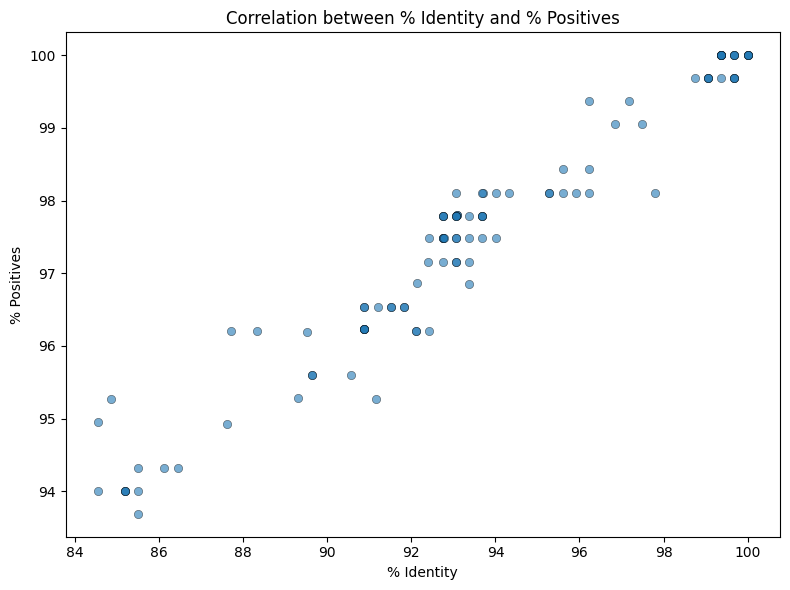

Pearson correlation coefficient: 0.9698


In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(df['% identity'], df['% positives'], alpha=0.6, edgecolors='k', linewidths=0.4)
plt.xlabel('% Identity')
plt.ylabel('% Positives')
plt.title('Correlation between % Identity and % Positives')
plt.tight_layout()
plt.show()

corr = df['% identity'].corr(df['% positives'])
print(f'Pearson correlation coefficient: {corr:.4f}')

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [46]:
protein_source_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv'
protein_df = pd.read_csv(protein_source_url)
print(protein_df.columns.tolist())
print(protein_df.head())

['Unnamed: 0', 'Protein', 'Source']
   Unnamed: 0         Protein   Source
0           0     NP_904328.1   RefSeq
1           2     YP_220563.1  GenPept
2          12  YP_002791042.1  GenPept
3          13  YP_001686698.1  GenPept
4          21  YP_009112408.1  GenPept


In [47]:
protein_df = pd.read_csv(protein_source_url)

# set protein as index
protein_df = protein_df.drop(columns=['Unnamed: 0']).set_index('Protein')

# Leftjoin on source column
df = df.join(protein_df['Source'], how='left')
df = df.rename(columns={'Source': 'Protein source'})
df['Protein source'] = df['Protein source'].fillna('NA')

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NA
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487.0,9.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947.0,47.0,NA
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106.0,13.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319.0,41.0,NA
